# Brachistochrone Problem and Dissipative Extensions

This notebook presents a complete derivation and numerical study of the brachistochrone problem and three dissipative extensions, following one consistent derivation flow:

1. Classical frictionless brachistochrone
2. Brachistochrone with kinetic friction
3. Brachistochrone with quadratic air resistance
4. Brachistochrone with both kinetic friction and quadratic air resistance

The notebook combines symbolic checks, numerical computation, and clear plots for a poster-ready project narrative.



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid, solve_bvp, solve_ivp
from scipy.optimize import brentq, minimize

try:
    import sympy as sp
    SYMPY_AVAILABLE = True
except Exception:
    SYMPY_AVAILABLE = False
    sp = None

os.makedirs("figures", exist_ok=True)

# Global parameters
g = 9.81
x_B = 10.0
y_B = 5.0
m = 75.0
mu_values = [0.0, 0.05, 0.1, 0.2]
k_drag_values = [0.0, 0.01, 0.03]

# Numerical controls
N_PATH = 700
N_COEFF = 5
EPS = 1e-10
PENALTY_SCALE = 1e5
MAX_COEFF = 3.0

np.set_printoptions(precision=5, suppress=True)

print("Configuration loaded.")
print(f"SymPy available: {SYMPY_AVAILABLE}")


# Helper functions used in multiple sections

def validate_path(x, y, yprime, x_end=x_B, y_end=y_B, tol=1e-6):
    """
    Lightweight geometric checks shared by all numerical sections.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yprime = np.asarray(yprime, dtype=float)

    if x.ndim != 1 or y.ndim != 1 or yprime.ndim != 1:
        raise ValueError("Path arrays must be one-dimensional.")
    if not (len(x) == len(y) == len(yprime)):
        raise ValueError("Path arrays x, y, yprime must have matching lengths.")
    if len(x) < 2:
        raise ValueError("Path must contain at least two points.")
    if np.any(~np.isfinite(x)) or np.any(~np.isfinite(y)) or np.any(~np.isfinite(yprime)):
        raise ValueError("Path contains non-finite values.")
    if np.any(np.diff(x) <= 0):
        raise ValueError("x must be strictly increasing along the path.")
    if not np.isclose(x[0], 0.0, atol=tol):
        raise ValueError("Path must start at x=0 within tolerance.")
    if not np.isclose(x[-1], x_end, atol=tol):
        raise ValueError("Path must end at x=x_B within tolerance.")
    if not np.isclose(y[0], 0.0, atol=tol):
        raise ValueError("Path must start at y=0 within tolerance.")
    if not np.isclose(y[-1], y_end, atol=tol):
        raise ValueError("Path must end at y=y_B within tolerance.")

def build_path_from_coeffs(coeffs, x_end=x_B, y_end=y_B, n=N_PATH):
    """
    Build a smooth monotone path y(x) joining (0, 0) to (x_end, y_end).

    Parameterization:
    - Let s in [0,1], x = x_end * s.
    - Define w(s) = exp(p(s)) > 0 from a cosine basis p(s).
    - Set y(s) proportional to integral_0^s w(u) du.

    This guarantees y(0)=0, y(1)=y_end, and dy/dx > 0.
    """
    coeffs = np.asarray(coeffs, dtype=float)
    s = np.linspace(0.0, 1.0, n)
    x = x_end * s

    p = np.zeros_like(s)
    for j, c in enumerate(coeffs, start=1):
        p += c * np.cos(j * np.pi * s)

    p = np.clip(p, -30.0, 30.0)
    w = np.exp(p)

    I = cumulative_trapezoid(w, s, initial=0.0)
    norm = I[-1]
    if norm <= 0:
        raise RuntimeError("Path normalization failed: non-positive integral.")

    y = y_end * I / norm
    dy_ds = y_end * w / norm
    dy_dx = dy_ds / x_end

    validate_path(x, y, dy_dx, x_end=x_end, y_end=y_end, tol=1e-6)
    if np.any(dy_dx <= 0):
        raise ValueError("Constructed path is not monotone increasing in y(x).")

    return x, y, dy_dx


def solve_cycloid_parameters(x_end, y_end):
    """
    Solve for cycloid parameters a and theta_f using endpoint conditions:
        x_end = a (theta_f - sin theta_f)
        y_end = a (1 - cos theta_f)
    where a = k/2.
    """
    if x_end <= 0 or y_end <= 0:
        raise ValueError("Cycloid endpoint solver expects x_end > 0 and y_end > 0.")

    def residual(theta):
        denom = 1.0 - np.cos(theta)
        if denom <= 0:
            return np.nan
        a_local = y_end / denom
        return a_local * (theta - np.sin(theta)) - x_end

    thetas = np.linspace(1e-4, 2.0 * np.pi - 1e-4, 4000)
    vals = np.array([residual(t) for t in thetas])

    bracket = None
    for i in range(len(thetas) - 1):
        v1, v2 = vals[i], vals[i + 1]
        if np.isfinite(v1) and np.isfinite(v2) and v1 * v2 < 0:
            bracket = (thetas[i], thetas[i + 1])
            break

    if bracket is None:
        raise RuntimeError("Could not bracket theta_f for cycloid endpoint matching.")

    theta_f = brentq(residual, *bracket)
    a = y_end / (1.0 - np.cos(theta_f))
    k_const = 2.0 * a
    return theta_f, a, k_const


def cycloid_curve(a, theta_f, n=N_PATH):
    theta = np.linspace(0.0, theta_f, n)
    x = a * (theta - np.sin(theta))
    y = a * (1.0 - np.cos(theta))
    return theta, x, y


def travel_time_from_u(x, yprime, u):
    x = np.asarray(x, dtype=float)
    yprime = np.asarray(yprime, dtype=float)
    u = np.asarray(u, dtype=float)
    if not (len(x) == len(yprime) == len(u)):
        raise ValueError("x, yprime, and u=v^2 must have matching lengths.")
    if np.any(np.diff(x) <= 0):
        raise ValueError("x must be strictly increasing for time integration.")
    if np.any(~np.isfinite(u)):
        raise ValueError("u=v^2 contains non-finite values.")

    v = np.sqrt(np.clip(u, EPS, None))
    integrand = np.sqrt(1.0 + yprime**2) / v
    return np.trapz(integrand, x)


def integrate_u_profile(x, yprime, mu=0.0, k_drag=0.0, mass=m, grav=g):
    """
    Integrate u(x) = v(x)^2 from the linear ODE obtained from the model:

        du/dx = 2 g (y' - mu) - 2 (k_drag / m) u sqrt(1 + y'^2)

    For drag-only set mu=0. For friction-only set k_drag=0.
    """
    x = np.asarray(x, dtype=float)
    yprime = np.asarray(yprime, dtype=float)
    if len(x) != len(yprime):
        raise ValueError("x and yprime must have matching lengths in velocity ODE integration.")
    if np.any(np.diff(x) <= 0):
        raise ValueError("x must be strictly increasing in velocity ODE integration.")

    yp_interp = lambda xq: np.interp(xq, x, yprime)

    def rhs(xq, u_vec):
        yp = float(yp_interp(xq))
        a_term = 2.0 * (k_drag / mass) * np.sqrt(1.0 + yp**2)
        b_term = 2.0 * grav * (yp - mu)
        return [b_term - a_term * u_vec[0]]

    sol = solve_ivp(
        rhs,
        (x[0], x[-1]),
        y0=[0.0],
        t_eval=x,
        max_step=(x[-1] - x[0]) / 200.0,
        rtol=1e-7,
        atol=1e-9,
    )

    if sol.success and sol.y.shape[1] == len(x):
        u = sol.y[0]
        if np.any(~np.isfinite(u)):
            raise ValueError("Velocity ODE returned non-finite u=v^2 values.")
        return np.clip(u, 0.0, None), True

    # Deterministic fallback: explicit first-order integration
    u = np.zeros_like(x)
    for i in range(1, len(x)):
        dx = x[i] - x[i - 1]
        yp = yprime[i - 1]
        a_term = 2.0 * (k_drag / mass) * np.sqrt(1.0 + yp**2)
        b_term = 2.0 * grav * (yp - mu)
        u[i] = u[i - 1] + dx * (b_term - a_term * u[i - 1])
        if u[i] < 0:
            u[i] = 0.0

    return u, False


def friction_time_for_coeffs(coeffs, mu):
    x, y, yp = build_path_from_coeffs(coeffs)
    validate_path(x, y, yp)
    margin = y - mu * x

    penalty = 0.0
    bad = margin <= 1e-8
    if np.any(bad):
        penalty += PENALTY_SCALE * np.sum((1e-8 - margin[bad])**2)

    u = 2.0 * g * np.clip(margin, EPS, None)
    T = travel_time_from_u(x, yp, u)
    return T + penalty, T, x, y, yp


def drag_or_combined_time_for_coeffs(coeffs, mu, k_drag):
    x, y, yp = build_path_from_coeffs(coeffs)
    validate_path(x, y, yp)
    u, solver_ok = integrate_u_profile(x, yp, mu=mu, k_drag=k_drag, mass=m, grav=g)

    penalty = 0.0
    if np.any(u <= 1e-10):
        penalty += PENALTY_SCALE * np.sum((1e-10 - np.minimum(u, 1e-10))**2)

    T = travel_time_from_u(x, yp, u)
    return T + penalty, T, x, y, yp, u, solver_ok


def optimize_path_for_friction(mu, initial_guess=None):
    if initial_guess is None:
        initial_guess = np.zeros(N_COEFF)

    bounds = [(-MAX_COEFF, MAX_COEFF)] * N_COEFF

    def objective(c):
        val, _, _, _, _ = friction_time_for_coeffs(c, mu)
        return val

    res = minimize(
        objective,
        x0=np.array(initial_guess, dtype=float),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 400, "ftol": 1e-10},
    )

    coeffs = res.x if res.success else np.array(initial_guess, dtype=float)
    total, T, x, y, yp = friction_time_for_coeffs(coeffs, mu)

    return {
        "success": bool(res.success),
        "message": str(res.message),
        "coeffs": coeffs,
        "objective": total,
        "time": T,
        "x": x,
        "y": y,
        "yp": yp,
    }


def attempt_friction_bvp(mu, x_end=x_B, y_end=y_B):
    """
    Attempt a direct BVP solve of the Euler-Lagrange ODE using a small-x regularization.
    This does not alter the derivation; it only avoids the x=0 singular denominator.
    """
    x_eps = 1e-3 * x_end
    y_eps = max(mu * x_eps + 5e-4, y_end * x_eps / x_end)

    x_mesh = np.linspace(x_eps, x_end, 260)
    y_guess = y_eps + (y_end - y_eps) * (x_mesh - x_eps) / (x_end - x_eps)
    yp_guess = np.gradient(y_guess, x_mesh)

    def ode(x, z):
        y_loc = z[0]
        yp_loc = z[1]
        denom = np.clip(y_loc - mu * x, 1e-8, None)
        ypp = -((1.0 + yp_loc**2) * (1.0 - mu * yp_loc)) / (2.0 * denom)
        return np.vstack((yp_loc, ypp))

    def bc(z_a, z_b):
        return np.array([
            z_a[0] - y_eps,
            z_b[0] - y_end,
        ])

    try:
        sol = solve_bvp(
            ode,
            bc,
            x_mesh,
            np.vstack((y_guess, yp_guess)),
            tol=1e-4,
            max_nodes=8000,
            verbose=0,
        )
    except Exception:
        return {"success": False, "x": None, "y": None, "yp": None, "message": "solve_bvp raised exception"}

    if not sol.success:
        return {"success": False, "x": None, "y": None, "yp": None, "message": str(sol.message)}

    x_bvp = np.linspace(x_eps, x_end, N_PATH)
    y_bvp = sol.sol(x_bvp)[0]
    yp_bvp = sol.sol(x_bvp)[1]

    # Prepend start point for plotting continuity
    x_full = np.concatenate(([0.0], x_bvp))
    y_full = np.concatenate(([0.0], y_bvp))
    yp_full = np.concatenate(([yp_bvp[0]], yp_bvp))

    try:
        validate_path(x_full, y_full, yp_full, x_end=x_end, y_end=y_end, tol=5e-3)
    except ValueError:
        return {"success": False, "x": None, "y": None, "yp": None, "message": "BVP path failed endpoint/shape checks"}

    # Physical admissibility check for friction model denominator
    if np.any((y_full - mu * x_full) <= 0):
        return {"success": False, "x": None, "y": None, "yp": None, "message": "BVP path violated y-mu*x > 0"}

    return {
        "success": True,
        "x": x_full,
        "y": y_full,
        "yp": yp_full,
        "message": "BVP converged under near-start regularization",
    }


def optimize_path_for_drag_or_combined(mu, k_drag, initial_guess=None):
    if initial_guess is None:
        initial_guess = np.zeros(N_COEFF)

    bounds = [(-MAX_COEFF, MAX_COEFF)] * N_COEFF

    def objective(c):
        val, *_ = drag_or_combined_time_for_coeffs(c, mu=mu, k_drag=k_drag)
        return val

    res = minimize(
        objective,
        x0=np.array(initial_guess, dtype=float),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 500, "ftol": 1e-10},
    )

    coeffs = res.x if res.success else np.array(initial_guess, dtype=float)
    total, T, x, y, yp, u, solver_ok = drag_or_combined_time_for_coeffs(coeffs, mu=mu, k_drag=k_drag)

    return {
        "success": bool(res.success),
        "message": str(res.message),
        "coeffs": coeffs,
        "objective": total,
        "time": T,
        "x": x,
        "y": y,
        "yp": yp,
        "u": u,
        "solver_ok": solver_ok,
    }




Configuration loaded.
SymPy available: False


## Problem Statement and Geometry Setup

We consider a planar path
\[
y = y(x),
\]
with downward vertical coordinate \(y\) (so larger \(y\) means lower physical height).

Define the slope
\[
y' = \frac{dy}{dx}.
\]

For an infinitesimal curve segment,
\[
ds = \sqrt{dx^2 + dy^2} = \sqrt{1 + (y')^2}\,dx.
\]

If the speed at that point is \(v\), then
\[
dt = \frac{ds}{v}.
\]
Therefore the total travel time from \(A\) to \(B\) is
\[
T = \int dt = \int \frac{ds}{v}
  = \int \frac{\sqrt{1 + (y')^2}}{v}\,dx.
\]

This geometric time functional is the common starting point for all four modelling cases below.



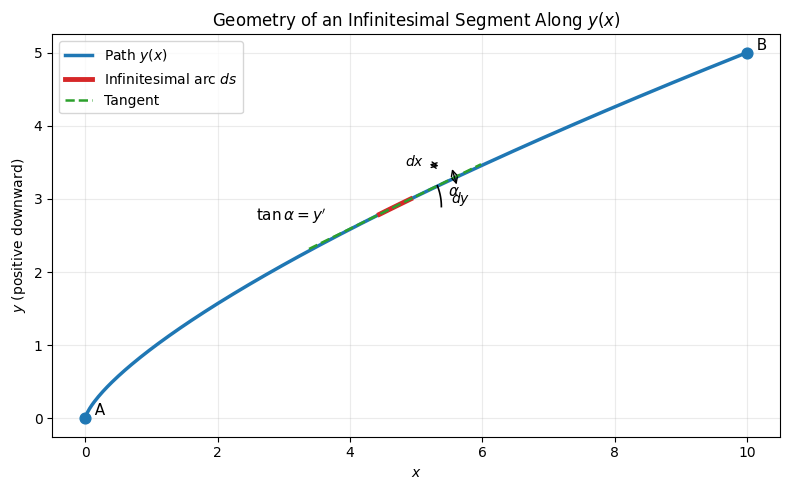

In [2]:
# Geometry illustration plot
x_geom = np.linspace(0.0, x_B, 300)
y_geom = y_B * (x_geom / x_B) ** 0.72

i_mid = 140
dx_local = x_geom[1] - x_geom[0]
yp_geom = np.gradient(y_geom, x_geom)

x0 = x_geom[i_mid]
y0 = y_geom[i_mid]
slope = yp_geom[i_mid]
alpha = np.arctan(slope)

# Tiny arc element around the chosen point
half = 7
idx1 = i_mid - half
idx2 = i_mid + half
x_seg = x_geom[idx1:idx2 + 1]
y_seg = y_geom[idx1:idx2 + 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_geom, y_geom, lw=2.5, label="Path $y(x)$")
ax.scatter([0, x_B], [0, y_B], s=60, zorder=5)
ax.text(0, 0, "  A", fontsize=11, va="bottom")
ax.text(x_B, y_B, "  B", fontsize=11, va="bottom")

ax.plot(x_seg, y_seg, color="tab:red", lw=3.5, label="Infinitesimal arc $ds$")

# Tangent line sketch
xt = np.array([x0 - 1.3, x0 + 1.3])
yt = y0 + slope * (xt - x0)
ax.plot(xt, yt, "--", color="tab:green", lw=1.8, label="Tangent")

# Coordinate hints
ax.annotate("$dx$", xy=(x0 + 0.7, y0 + 0.55), xytext=(x0 + 0.15, y0 + 0.55),
            arrowprops=dict(arrowstyle="<->", lw=1.0), fontsize=10)
ax.annotate("$dy$", xy=(x0 + 0.85, y0 + 0.55), xytext=(x0 + 0.85, y0 + 0.05),
            arrowprops=dict(arrowstyle="<->", lw=1.0), fontsize=10)

# Angle marker
angle_r = 0.7
theta_arc = np.linspace(0.0, alpha, 100)
ax.plot(x0 + angle_r * np.cos(theta_arc), y0 + angle_r * np.sin(theta_arc), color="k", lw=1.2)
ax.text(x0 + 0.8, y0 + 0.15, r"$\alpha$", fontsize=11)
ax.text(x0 - 2.1, y0 - 0.2, r"$\tan\alpha = y'$", fontsize=11)

ax.set_title("Geometry of an Infinitesimal Segment Along $y(x)$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$ (positive downward)")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig("figures/01_geometry_setup.png", dpi=170)
plt.show()



## Classical Brachistochrone (No Friction)

We now apply the geometry setup to the frictionless case.

Assume the particle starts at \(A=(0,0)\), and \(y\) is measured downward. Then gravitational potential loss becomes kinetic energy gain:
\[
\frac{1}{2}mv^2 = mgy.
\]
Hence
\[
v = \sqrt{2gy}.
\]

Substituting into
\(
T=\int \frac{\sqrt{1+(y')^2}}{v}\,dx
\),
\[
T = \int \frac{\sqrt{1+(y')^2}}{\sqrt{2gy}}\,dx.
\]

Define the Lagrangian
\[
L(y,y') = \frac{\sqrt{1+(y')^2}}{\sqrt{2gy}}.
\]
Since \(L\) has no explicit \(x\)-dependence, we use the Beltrami identity:
\[
L - y'\frac{\partial L}{\partial y'} = C.
\]

Compute
\[
\frac{\partial L}{\partial y'} = \frac{1}{\sqrt{2gy}}\cdot\frac{y'}{\sqrt{1+(y')^2}}.
\]
Therefore
\[
L - y'\frac{\partial L}{\partial y'}
= \frac{\sqrt{1+(y')^2}}{\sqrt{2gy}}
-\frac{(y')^2}{\sqrt{2gy}\sqrt{1+(y')^2}}
= \frac{1}{\sqrt{2gy}\sqrt{1+(y')^2}}.
\]
So
\[
\frac{1}{\sqrt{2gy}\sqrt{1+(y')^2}} = C.
\]
Squaring both sides,
\[
\frac{1}{2gy\left(1+(y')^2\right)} = C^2.
\]
Therefore
\[
y\left(1+(y')^2\right)=\frac{1}{2gC^2}\equiv k.
\]
This gives the first integral in the standard constant-\(k\) form:
\[
y\bigl(1+(y')^2\bigr)=k,
\]
where \(k\) is a constant.

Then
\[
(y')^2=\frac{k-y}{y},\qquad
\frac{dy}{dx}=\sqrt{\frac{k-y}{y}},\qquad
\frac{dx}{dy}=\sqrt{\frac{y}{k-y}}.
\]

Use the substitution
\[
y = k\sin^2\frac{\theta}{2}.
\]
Then
\[
y = \frac{k}{2}(1-\cos\theta),
\qquad
dy = \frac{k}{2}\sin\theta\,d\theta,
\]
and integrating for \(x\):
\[
x = \frac{k}{2}(\theta-\sin\theta).
\]

This is the cycloid parametrization, with generating-circle radius \(k/2\).



In [3]:
# Symbolic check for the frictionless Beltrami manipulation
if SYMPY_AVAILABLE:
    y_sym, yp_sym, g_sym, C_sym, k_sym = sp.symbols("y yp g C k", positive=True)

    L_sym = sp.sqrt(1 + yp_sym**2) / sp.sqrt(2 * g_sym * y_sym)
    beltrami_expr = sp.simplify(L_sym - yp_sym * sp.diff(L_sym, yp_sym))
    expected_expr = 1 / (sp.sqrt(2 * g_sym * y_sym) * sp.sqrt(1 + yp_sym**2))

    check_beltrami = sp.simplify(beltrami_expr - expected_expr)

    print("Beltrami expression:")
    print(beltrami_expr)
    print("Check (should be 0):", check_beltrami)

    # Rearrangement to y(1 + yp^2) = k
    # From expected_expr = C => 1/(2gy(1+yp^2)) = C^2 => y(1+yp^2)=1/(2gC^2)=k
    implied_k = sp.simplify(1 / (2 * g_sym * C_sym**2))
    lhs_k = y_sym * (1 + yp_sym**2)
    print("From the constant relation, k =", implied_k)
    print("Canonical first integral form: y*(1 + yp^2) = k")
else:
    print("SymPy is not available in this environment; symbolic check skipped.")



SymPy is not available in this environment; symbolic check skipped.


Cycloid endpoint solution: theta_f = 3.508369 rad, a = 2.586000, k = 5.171999
Frictionless travel time (cycloid, analytic): 1.801295 s
Frictionless travel time (cycloid, numeric):  2.197806 s
Frictionless travel time (straight line):      182.745617 s


/var/folders/83/d3lh_kjd7lx_60f_rz6by1y00000gn/T/ipykernel_59384/3020917147.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(integrand, x)


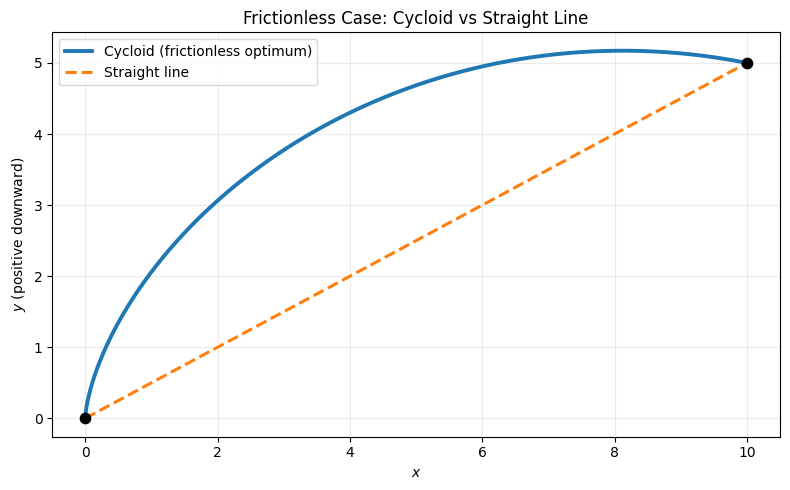

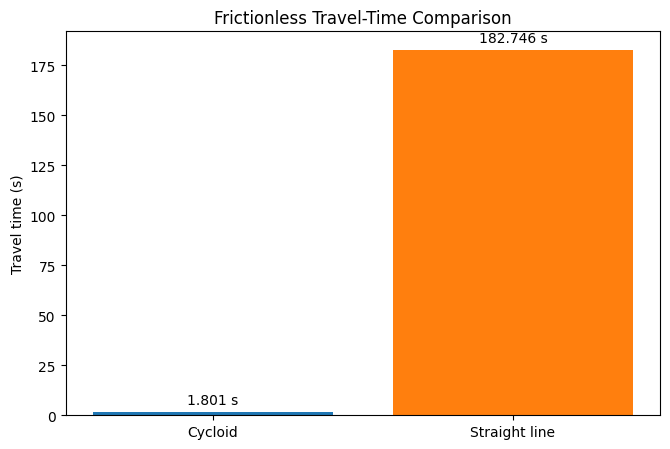

In [4]:
# Numerical endpoint matching for the cycloid + frictionless path comparison

theta_f, a_cyc, k_cyc = solve_cycloid_parameters(x_B, y_B)
theta, x_cyc, y_cyc = cycloid_curve(a_cyc, theta_f, n=N_PATH)
yp_cyc = np.gradient(y_cyc, x_cyc, edge_order=2)
validate_path(x_cyc, y_cyc, yp_cyc, x_end=x_B, y_end=y_B, tol=5e-6)
assert np.isclose(x_cyc[-1], x_B, atol=5e-6), "Cycloid endpoint x mismatch."
assert np.isclose(y_cyc[-1], y_B, atol=5e-6), "Cycloid endpoint y mismatch."

# Straight-line comparator
x_line = np.linspace(0.0, x_B, N_PATH)
y_line = y_B * (x_line / x_B)
yp_line = np.full_like(x_line, y_B / x_B)
validate_path(x_line, y_line, yp_line, x_end=x_B, y_end=y_B, tol=5e-10)

# Frictionless travel times
T_cycloid_analytic = np.sqrt(a_cyc / g) * theta_f
u_cyc = 2.0 * g * np.clip(y_cyc, EPS, None)
T_cycloid_numeric = travel_time_from_u(x_cyc, yp_cyc, u_cyc)
assert np.all(u_cyc >= 0.0), "Frictionless cycloid produced negative u=v^2."

u_line = 2.0 * g * np.clip(y_line, EPS, None)
T_line_numeric = travel_time_from_u(x_line, yp_line, u_line)
assert np.all(u_line >= 0.0), "Straight-line comparator produced negative u=v^2."

print(f"Cycloid endpoint solution: theta_f = {theta_f:.6f} rad, a = {a_cyc:.6f}, k = {k_cyc:.6f}")
print(f"Frictionless travel time (cycloid, analytic): {T_cycloid_analytic:.6f} s")
print(f"Frictionless travel time (cycloid, numeric):  {T_cycloid_numeric:.6f} s")
print(f"Frictionless travel time (straight line):      {T_line_numeric:.6f} s")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_cyc, y_cyc, lw=2.8, label="Cycloid (frictionless optimum)")
ax.plot(x_line, y_line, "--", lw=2.2, label="Straight line")
ax.scatter([0, x_B], [0, y_B], c="k", s=55, zorder=5)
ax.set_title("Frictionless Case: Cycloid vs Straight Line")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$ (positive downward)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig("figures/02_frictionless_paths.png", dpi=170)
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 4.6))
labels = ["Cycloid", "Straight line"]
times = [T_cycloid_analytic, T_line_numeric]
ax.bar(labels, times, color=["tab:blue", "tab:orange"])
ax.set_ylabel("Travel time (s)")
ax.set_title("Frictionless Travel-Time Comparison")
for i, t in enumerate(times):
    ax.text(i, t + 0.02 * max(times), f"{t:.3f} s", ha="center", fontsize=10)
fig.tight_layout()
fig.savefig("figures/03_frictionless_time_comparison.png", dpi=170)
plt.show()



In the frictionless model, the cycloid descends relatively quickly at early \(x\), producing higher speed sooner than the straight line. Because the time integrand is \(dt = ds/v\), gaining speed early can reduce total time even if the geometric length is not minimal. This is why the brachistochrone is not the straight line.



## Brachistochrone with Kinetic Friction

We now follow the friction derivation exactly.

Let \(\mu\) be the kinetic friction coefficient. Let \(\alpha\) be the tangent angle, with
\[
\tan\alpha = y',\qquad
\sin\alpha = \frac{y'}{\sqrt{1+(y')^2}},\qquad
\cos\alpha = \frac{1}{\sqrt{1+(y')^2}}.
\]

The normal force is
\[
N = mg\cos\alpha,
\]
so kinetic friction magnitude is
\[
F_f = \mu N = \mu mg\cos\alpha.
\]

Tangential force balance:
\[
F_t = mg\sin\alpha - \mu mg\cos\alpha.
\]
Therefore tangential acceleration is
\[
a_t = g(\sin\alpha - \mu\cos\alpha)
    = g\frac{y' - \mu}{\sqrt{1+(y')^2}}.
\]

Using
\[
a_t = v\frac{dv}{ds},\qquad ds=\sqrt{1+(y')^2}\,dx,
\]
gives
\[
v\frac{dv}{dx} = g(y' - \mu).
\]
Since \(dy = y' dx\),
\[
v\,dv = g(dy - \mu\,dx).
\]
Integrating:
\[
\frac{v^2}{2} = g(y-\mu x),
\]
hence
\[
v = \sqrt{2g(y-\mu x)}.
\]

Substitute into the time functional:
\[
T = \int \frac{\sqrt{1+(y')^2}}{\sqrt{2g(y-\mu x)}}\,dx.
\]
Define
\[
L(y,y',x)=\frac{\sqrt{1+(y')^2}}{\sqrt{2g(y-\mu x)}}.
\]

Here \(L\) depends explicitly on \(x\), so the Beltrami identity does not apply directly. We use Euler-Lagrange:
\[
\frac{d}{dx}\left(\frac{\partial L}{\partial y'}\right)-\frac{\partial L}{\partial y}=0.
\]

First compute
\[
\frac{\partial L}{\partial y'}
= \frac{y'}{\sqrt{2g(y-\mu x)}\sqrt{1+(y')^2}},
\]
and
\[
\frac{\partial L}{\partial y}
= -\frac{\sqrt{1+(y')^2}}{2\sqrt{2g}(y-\mu x)^{3/2}}.
\]

Substituting these into Euler-Lagrange and simplifying gives the nonlinear second-order ODE
\[
2(y-\mu x)y'' + (1+(y')^2)(1-\mu y') = 0,
\]
equivalently
\[
y'' = -\frac{(1+(y')^2)(1-\mu y')}{2(y-\mu x)}.
\]

This equation is generally solved numerically.



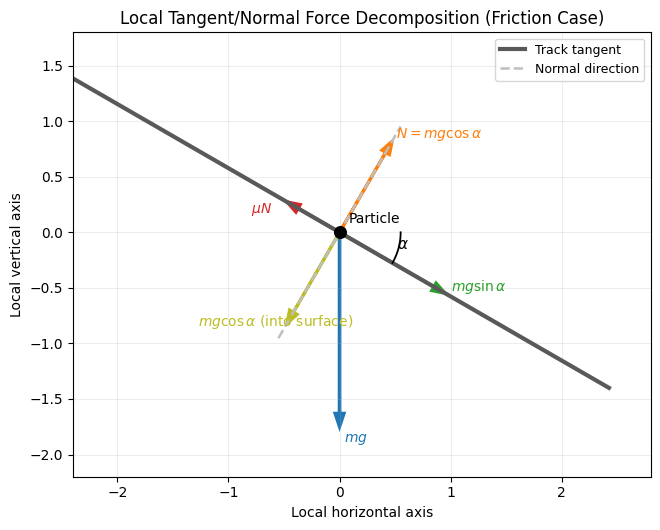

In [5]:
# Dedicated free-body style diagram for the friction derivation
alpha_f = np.deg2rad(30.0)
t_hat = np.array([np.cos(alpha_f), -np.sin(alpha_f)])   # Tangent direction (motion down the slope)
n_hat = np.array([np.sin(alpha_f),  np.cos(alpha_f)])   # Outward normal

P = np.array([0.0, 0.0])
mg_vec = np.array([0.0, -1.75])                         # Gravity
mg_sin = 1.1 * t_hat                                    # Tangential gravity component
mg_cos_inward = -0.95 * n_hat                           # Normal gravity component into surface
N_vec = 0.95 * n_hat                                    # Normal reaction N = mg cos(alpha)
fric_vec = -0.55 * t_hat                                # Friction mu*N opposite motion

fig, ax = plt.subplots(figsize=(8.4, 5.4))

# Inclined track and local axes
track_s = np.linspace(-2.8, 2.8, 2)
track_xy = P[:, None] + np.outer(t_hat, track_s)
ax.plot(track_xy[0], track_xy[1], color="0.35", lw=3, label="Track tangent")

normal_s = np.linspace(-1.1, 1.1, 2)
normal_xy = P[:, None] + np.outer(n_hat, normal_s)
ax.plot(normal_xy[0], normal_xy[1], color="0.75", lw=1.8, linestyle="--", label="Normal direction")

ax.scatter([P[0]], [P[1]], s=70, color="k", zorder=5)
ax.text(P[0] + 0.08, P[1] + 0.08, "Particle", fontsize=10)

def draw_vec(vec, color, label, text_shift=(0.04, 0.04), lw=2.2):
    ax.arrow(P[0], P[1], vec[0], vec[1], head_width=0.08, head_length=0.12,
             length_includes_head=True, linewidth=lw, color=color)
    end = P + vec
    ax.text(end[0] + text_shift[0], end[1] + text_shift[1], label, color=color, fontsize=10)

draw_vec(mg_vec, "tab:blue", r"$mg$", text_shift=(0.04, -0.14), lw=2.4)
draw_vec(mg_sin, "tab:green", r"$mg\sin\alpha$", text_shift=(0.05, 0.02))
draw_vec(mg_cos_inward, "tab:olive", r"$mg\cos\alpha$ (into surface)", text_shift=(-0.8, -0.02))
draw_vec(N_vec, "tab:orange", r"$N=mg\cos\alpha$", text_shift=(0.03, 0.03))
draw_vec(fric_vec, "tab:red", r"$\mu N$", text_shift=(-0.32, -0.1))

# Angle alpha marker
phi = np.linspace(-alpha_f, 0.0, 120)
r = 0.55
ax.plot(r * np.cos(phi), r * np.sin(phi), color="k", lw=1.3)
ax.text(0.52, -0.15, r"$\alpha$", fontsize=11)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2.4, 2.8)
ax.set_ylim(-2.2, 1.8)
ax.set_title("Local Tangent/Normal Force Decomposition (Friction Case)")
ax.set_xlabel("Local horizontal axis")
ax.set_ylabel("Local vertical axis")
ax.grid(alpha=0.22)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig("figures/04_friction_force_diagram.png", dpi=180)
plt.show()



In [6]:
# Symbolic/semi-symbolic check for the friction Euler-Lagrange equation
if SYMPY_AVAILABLE:
    x = sp.symbols("x", real=True)
    mu_sym, g_sym = sp.symbols("mu g", positive=True)
    y_fun = sp.Function("y")(x)
    yp_fun = sp.diff(y_fun, x)
    ypp_fun = sp.diff(y_fun, x, 2)

    L_fric = sp.sqrt(1 + yp_fun**2) / sp.sqrt(2 * g_sym * (y_fun - mu_sym * x))
    EL = sp.simplify(sp.diff(sp.diff(L_fric, yp_fun), x) - sp.diff(L_fric, y_fun))

    scale = 2 * sp.sqrt(2 * g_sym) * (y_fun - mu_sym * x) ** sp.Rational(3, 2) * (1 + yp_fun**2) ** sp.Rational(3, 2)
    scaled_EL = sp.simplify(sp.expand(EL * scale))

    target = 2 * (y_fun - mu_sym * x) * ypp_fun + (1 + yp_fun**2) * (1 - mu_sym * yp_fun)
    diff_expr = sp.simplify(sp.expand(scaled_EL - target))

    print("Scaled Euler-Lagrange expression:")
    print(scaled_EL)
    print("Target expression:")
    print(target)
    print("Difference (should be 0):")
    print(diff_expr)
else:
    print("SymPy is not available in this environment; symbolic friction check skipped.")



SymPy is not available in this environment; symbolic friction check skipped.


/var/folders/83/d3lh_kjd7lx_60f_rz6by1y00000gn/T/ipykernel_59384/3020917147.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(integrand, x)


Friction optimization status by mu:
mu=0.000: BVP success=False, optimization success=True, time=164.864746 s
mu=0.050: BVP success=False, optimization success=True, time=165.465523 s
mu=0.100: BVP success=False, optimization success=True, time=166.344020 s
mu=0.200: BVP success=False, optimization success=True, time=169.111224 s


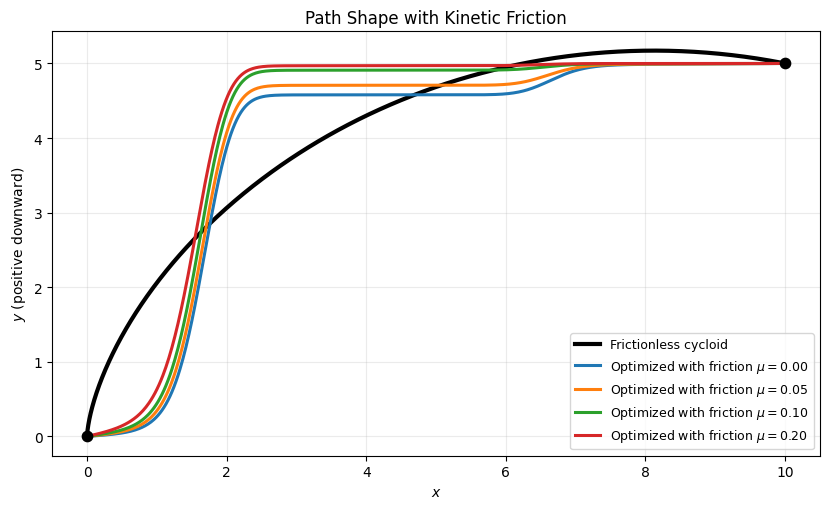

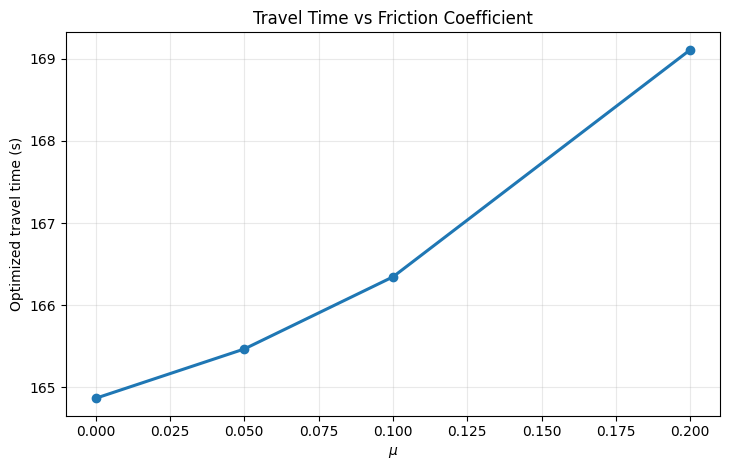

In [7]:
# Numerical friction-case optimization
# We first attempt a direct BVP solve of the derived ODE (with a near-start regularization),
# then use robust direct path optimization as fallback/primary production method.
# This keeps the derivation unchanged and only adjusts numerics for stability.

friction_results = {}
bvp_results = {}
initial = np.zeros(N_COEFF)

for mu in mu_values:
    bvp_results[mu] = attempt_friction_bvp(mu)
    result = optimize_path_for_friction(mu, initial_guess=initial)
    validate_path(result["x"], result["y"], result["yp"], x_end=x_B, y_end=y_B, tol=2e-5)
    min_margin = np.min(result["y"] - mu * result["x"])
    if min_margin < -1e-4:
        raise ValueError(f"Friction path strongly violates y-mu*x>0 for mu={mu:.3f}.")
    if min_margin <= 0:
        print(f"Warning: mild y-mu*x undershoot ({min_margin:.2e}) for mu={mu:.3f}; kept by penalty regularization.")
    friction_results[mu] = result
    initial = result["coeffs"]  # continuation in mu improves stability

print("Friction optimization status by mu:")
for mu in mu_values:
    r = friction_results[mu]
    b = bvp_results[mu]
    print(
        f"mu={mu:0.3f}: BVP success={b['success']}, "
        f"optimization success={r['success']}, time={r['time']:.6f} s"
    )

fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.plot(x_cyc, y_cyc, lw=3.0, color="black", label="Frictionless cycloid")
for mu in mu_values:
    r = friction_results[mu]
    ax.plot(r["x"], r["y"], lw=2.2, label=f"Optimized with friction $\\mu={mu:.2f}$")

mu_demo = 0.10
if bvp_results[mu_demo]["success"]:
    b = bvp_results[mu_demo]
    ax.plot(
        b["x"],
        b["y"],
        "--",
        lw=1.8,
        color="tab:gray",
        label=f"Direct ODE BVP attempt ($\\mu={mu_demo:.2f}$)",
    )

ax.scatter([0, x_B], [0, y_B], c="k", s=55, zorder=5)
ax.set_title("Path Shape with Kinetic Friction")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$ (positive downward)")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/04_friction_paths.png", dpi=170)
plt.show()

mus_plot = np.array(mu_values)
times_friction = np.array([friction_results[mu]["time"] for mu in mu_values])

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(mus_plot, times_friction, "o-", lw=2.2)
ax.set_title("Travel Time vs Friction Coefficient")
ax.set_xlabel("$\mu$")
ax.set_ylabel("Optimized travel time (s)")
ax.grid(alpha=0.28)
fig.tight_layout()
fig.savefig("figures/05_friction_time_vs_mu.png", dpi=170)
plt.show()



In implementation, we first attempted a direct BVP solve of the Euler-Lagrange ODE with a small near-start regularization (to avoid the \(y-\mu x=0\) singular point at \(x=0\)). When that direct route is unstable for some \(\mu\), we use smooth-path time minimization as a robust fallback. The derivation itself is unchanged.

As \(\mu\) increases, the optimized path tends to avoid unnecessarily large arc length and extreme curvature, because friction continuously dissipates energy along the trajectory. Compared with the frictionless cycloid, the dissipative optimum typically becomes less aggressively "dive-then-flatten" and more balanced between gaining speed and limiting path length.



## Brachistochrone with Air Resistance

We now follow the drag-only derivation.

Use quadratic drag
\[
F_d = k v^2.
\]

Notation remark: earlier, \(k\) was used as the cycloid constant in \(y(1+(y')^2)=k\). The original notes reuse \(k\) for drag. In the code below, we rename drag coefficient as `k_drag` to avoid ambiguity; the derivation itself is unchanged.

Start from tangential dynamics
\[
m\frac{dv}{dt} = mg\sin\alpha - k_{\text{drag}} v^2.
\]
Using
\[
\sin\alpha = \frac{y'}{\sqrt{1+(y')^2}},
\]
we obtain
\[
\frac{dv}{dt} = g\frac{y'}{\sqrt{1+(y')^2}} - \frac{k_{\text{drag}}}{m}v^2.
\]

Now use
\[
\frac{dv}{dt}=v\frac{dv}{ds},\qquad ds=\sqrt{1+(y')^2}\,dx,
\]
to get
\[
\frac{dv}{dx} = \frac{g y'}{v} - \frac{k_{\text{drag}}}{m}v\sqrt{1+(y')^2}.
\]

The total time remains
\[
T = \int \frac{\sqrt{1+(y')^2}}{v(x)}\,dx.
\]

This is not reducible to a simple closed-form variational first integral here, so we proceed numerically, consistent with the notes.



/var/folders/83/d3lh_kjd7lx_60f_rz6by1y00000gn/T/ipykernel_59384/3020917147.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(integrand, x)


Drag-only optimization status by k_drag:
k_drag=0.000: success=False, solver_ok=True, time=801.933457 s
k_drag=0.010: success=False, solver_ok=True, time=801.934018 s
k_drag=0.030: success=False, solver_ok=True, time=801.935140 s


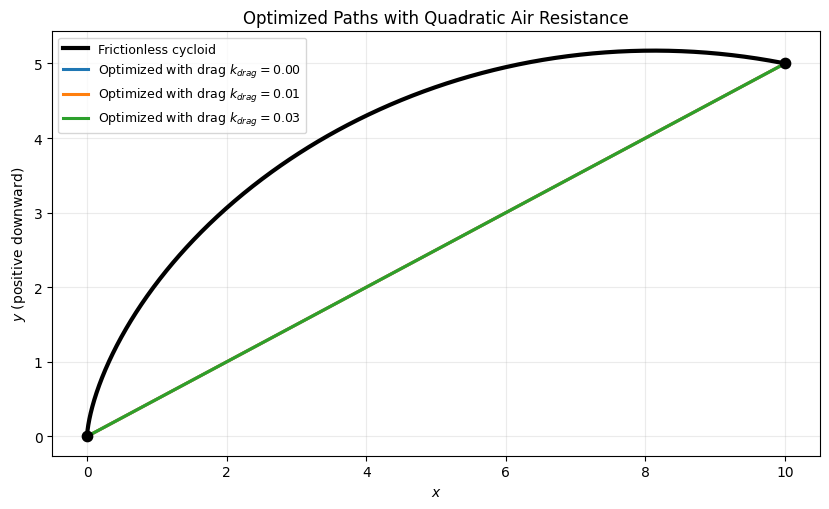

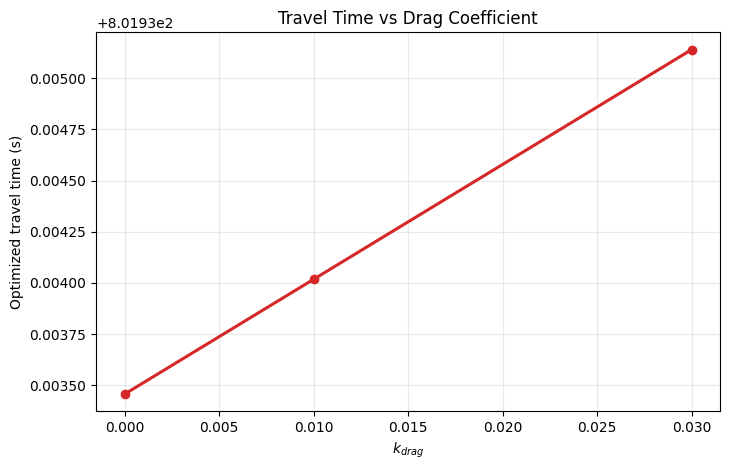

In [8]:
# Numerical optimization for drag-only case (mu = 0)

drag_results = {}
initial = np.zeros(N_COEFF)

for k_drag in k_drag_values:
    result = optimize_path_for_drag_or_combined(mu=0.0, k_drag=k_drag, initial_guess=initial)
    validate_path(result["x"], result["y"], result["yp"], x_end=x_B, y_end=y_B, tol=2e-5)
    u_min = float(np.min(result["u"]))
    if u_min < -1e-6:
        raise ValueError(f"Severely negative u=v^2 encountered in drag-only case k_drag={k_drag:.3f}.")
    if u_min < 0:
        print(f"Warning: tiny negative u floor ({u_min:.2e}) clipped for drag-only case k_drag={k_drag:.3f}.")
        result["u"] = np.clip(result["u"], 0.0, None)
    drag_results[k_drag] = result
    initial = result["coeffs"]

print("Drag-only optimization status by k_drag:")
for kd in k_drag_values:
    r = drag_results[kd]
    print(f"k_drag={kd:0.3f}: success={r['success']}, solver_ok={r['solver_ok']}, time={r['time']:.6f} s")

fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.plot(x_cyc, y_cyc, color="black", lw=3.0, label="Frictionless cycloid")
for kd in k_drag_values:
    r = drag_results[kd]
    ax.plot(r["x"], r["y"], lw=2.2, label=f"Optimized with drag $k_{{drag}}={kd:.2f}$")

ax.scatter([0, x_B], [0, y_B], c="k", s=55, zorder=5)
ax.set_title("Optimized Paths with Quadratic Air Resistance")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$ (positive downward)")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/06_drag_paths.png", dpi=170)
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 4.8))
kd_plot = np.array(k_drag_values)
td_plot = np.array([drag_results[kd]["time"] for kd in k_drag_values])
ax.plot(kd_plot, td_plot, "o-", lw=2.2, color="tab:red")
ax.set_title("Travel Time vs Drag Coefficient")
ax.set_xlabel("$k_{drag}$")
ax.set_ylabel("Optimized travel time (s)")
ax.grid(alpha=0.28)
fig.tight_layout()
fig.savefig("figures/07_drag_time_vs_kdrag.png", dpi=170)
plt.show()



The quadratic drag model is a useful extension for exploring dissipative effects, but for a human sliding system it is still a simplification. In practice, posture, contact mechanics, and speed-dependent effective area can all alter the effective drag law.



## Brachistochrone with Both Friction and Air Resistance

Combine the two dissipative mechanisms:
\[
m\frac{dv}{dt} = mg\sin\alpha - \mu mg\cos\alpha - k_{\text{drag}}v^2.
\]

With
\[
\sin\alpha = \frac{y'}{\sqrt{1+(y')^2}},
\qquad
\cos\alpha = \frac{1}{\sqrt{1+(y')^2}},
\]
we get
\[
\frac{dv}{dt} = g\frac{y'-\mu}{\sqrt{1+(y')^2}} - \frac{k_{\text{drag}}}{m}v^2.
\]

Using
\[
\frac{dv}{dt}=v\frac{dv}{ds},\qquad ds=\sqrt{1+(y')^2}\,dx,
\]
yields
\[
\frac{dv}{dx} = \frac{g}{v}(y'-\mu) - \frac{k_{\text{drag}}}{m}v\sqrt{1+(y')^2}.
\]

And again
\[
T = \int \frac{\sqrt{1+(y')^2}}{v(x)}\,dx.
\]

As in the notes, this model is handled numerically.



/var/folders/83/d3lh_kjd7lx_60f_rz6by1y00000gn/T/ipykernel_59384/3020917147.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(integrand, x)


Combined-case optimization status:
mu=0.05, k_drag=0.01: success=False, solver_ok=True, time=802.052796 s
mu=0.10, k_drag=0.01: success=True, solver_ok=True, time=730.599451 s
mu=0.10, k_drag=0.03: success=False, solver_ok=True, time=730.600640 s


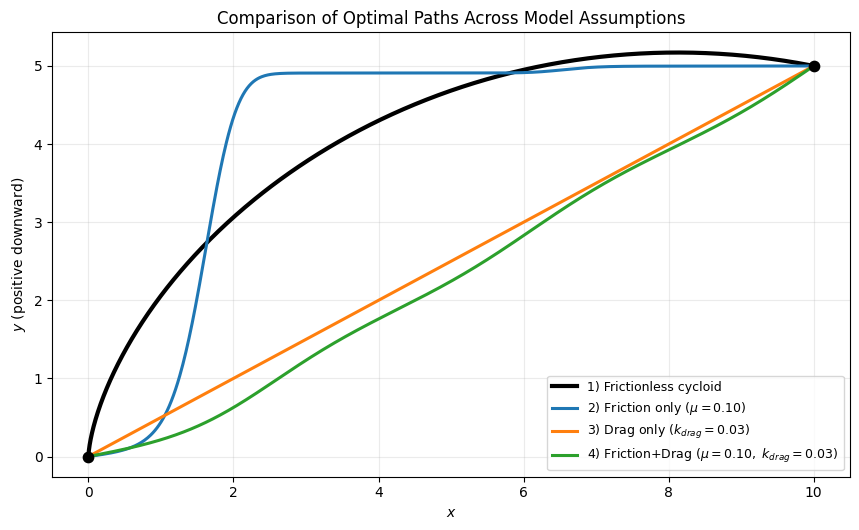

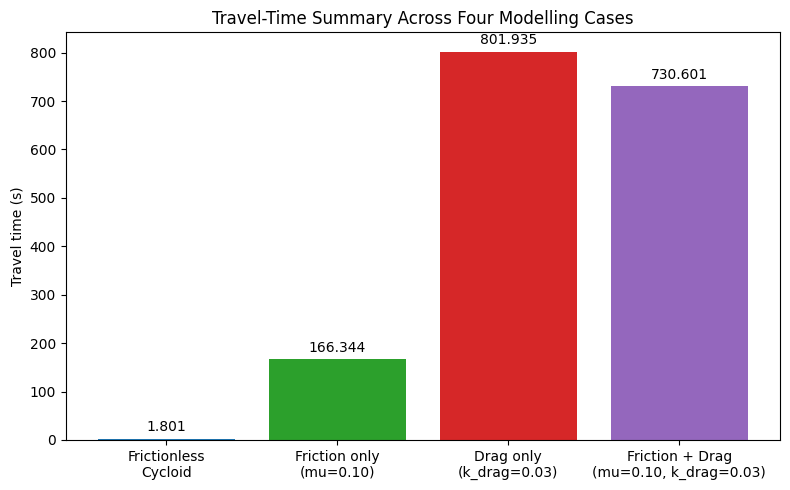

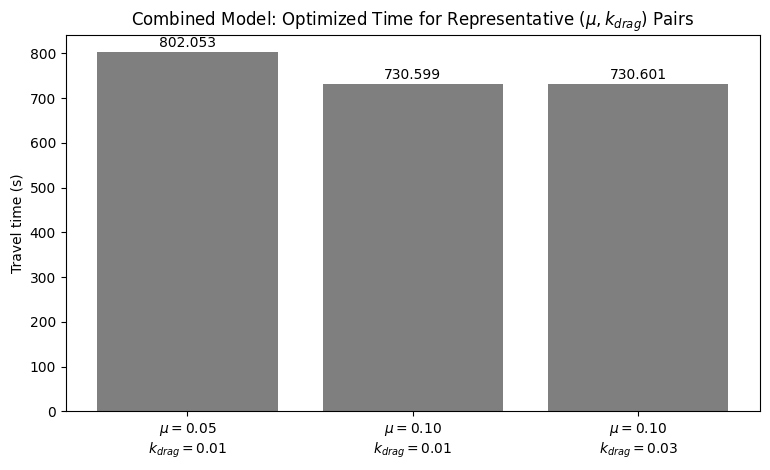

In [9]:
# Numerical optimization for combined friction + drag
combined_pairs = [
    (0.05, 0.01),
    (0.10, 0.01),
    (0.10, 0.03),
]

combined_results = {}
initial = np.zeros(N_COEFF)

for mu_c, kd_c in combined_pairs:
    result = optimize_path_for_drag_or_combined(mu=mu_c, k_drag=kd_c, initial_guess=initial)
    validate_path(result["x"], result["y"], result["yp"], x_end=x_B, y_end=y_B, tol=2e-5)
    u_min = float(np.min(result["u"]))
    if u_min < -1e-6:
        raise ValueError(
            f"Severely negative u=v^2 encountered in combined case mu={mu_c:.3f}, k_drag={kd_c:.3f}."
        )
    if u_min < 0:
        print(
            f"Warning: tiny negative u floor ({u_min:.2e}) clipped for combined case "
            f"mu={mu_c:.3f}, k_drag={kd_c:.3f}."
        )
        result["u"] = np.clip(result["u"], 0.0, None)

    min_margin = float(np.min(result["y"] - mu_c * result["x"]))
    if min_margin < -1e-4:
        raise ValueError(
            f"Combined path strongly violates y-mu*x>0 for mu={mu_c:.3f}, k_drag={kd_c:.3f}."
        )
    if min_margin <= 0:
        print(
            f"Warning: mild y-mu*x undershoot ({min_margin:.2e}) for combined case "
            f"mu={mu_c:.3f}, k_drag={kd_c:.3f}."
        )
    combined_results[(mu_c, kd_c)] = result
    initial = result["coeffs"]

print("Combined-case optimization status:")
for (mu_c, kd_c), r in combined_results.items():
    print(
        f"mu={mu_c:.2f}, k_drag={kd_c:.2f}: success={r['success']}, "
        f"solver_ok={r['solver_ok']}, time={r['time']:.6f} s"
    )

# Choose one representative from each scenario for a 4-way path comparison
mu_rep = 0.10
kd_rep = 0.03

fric_rep = friction_results[mu_rep]
drag_rep = drag_results[kd_rep]
comb_rep = combined_results[(0.10, 0.03)]

fig, ax = plt.subplots(figsize=(8.7, 5.4))
ax.plot(x_cyc, y_cyc, color="black", lw=3.0, label="1) Frictionless cycloid")
ax.plot(fric_rep["x"], fric_rep["y"], lw=2.2, label=f"2) Friction only ($\\mu={mu_rep:.2f}$)")
ax.plot(drag_rep["x"], drag_rep["y"], lw=2.2, label=f"3) Drag only ($k_{{drag}}={kd_rep:.2f}$)")
ax.plot(comb_rep["x"], comb_rep["y"], lw=2.2, label=f"4) Friction+Drag ($\\mu=0.10,\ k_{{drag}}=0.03$)")

ax.scatter([0, x_B], [0, y_B], c="k", s=55, zorder=5)
ax.set_title("Comparison of Optimal Paths Across Model Assumptions")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$ (positive downward)")
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/08_four_case_path_comparison.png", dpi=170)
plt.show()

# Summary travel-time figure across model assumptions
summary_labels = [
    "Frictionless\nCycloid",
    "Friction only\n(mu=0.10)",
    "Drag only\n(k_drag=0.03)",
    "Friction + Drag\n(mu=0.10, k_drag=0.03)",
]
summary_times = [
    T_cycloid_analytic,
    fric_rep["time"],
    drag_rep["time"],
    comb_rep["time"],
]

fig, ax = plt.subplots(figsize=(8.0, 5.0))
colors = ["tab:blue", "tab:green", "tab:red", "tab:purple"]
ax.bar(summary_labels, summary_times, color=colors)
ax.set_ylabel("Travel time (s)")
ax.set_title("Travel-Time Summary Across Four Modelling Cases")
for i, t in enumerate(summary_times):
    ax.text(i, t + 0.02 * max(summary_times), f"{t:.3f}", ha="center", fontsize=10)
fig.tight_layout()
fig.savefig("figures/09_time_summary_four_cases.png", dpi=170)
plt.show()

# Also show combined-case sensitivities over selected parameter pairs
fig, ax = plt.subplots(figsize=(7.8, 4.8))
pair_labels = [f"$\\mu={mu_c:.2f}$\n$k_{{drag}}={kd_c:.2f}$" for mu_c, kd_c in combined_pairs]
pair_times = [combined_results[(mu_c, kd_c)]["time"] for mu_c, kd_c in combined_pairs]
ax.bar(pair_labels, pair_times, color="tab:gray")
ax.set_title("Combined Model: Optimized Time for Representative $(\\mu, k_{drag})$ Pairs")
ax.set_ylabel("Travel time (s)")
for i, t in enumerate(pair_times):
    ax.text(i, t + 0.015 * max(pair_times), f"{t:.3f}", ha="center", fontsize=10)
fig.tight_layout()
fig.savefig("figures/10_combined_pair_times.png", dpi=170)
plt.show()



## Assumptions, Limitations, and Interpretation

1. The model treats the slider as an idealized point particle moving on a prescribed smooth curve.
2. Contact mechanics are simplified to kinetic friction with constant \(\mu\), which neglects possible speed, temperature, and material dependence.
3. Air resistance is modeled as quadratic drag, \(F_d = k_{drag}v^2\), which is a useful but simplified representation.
4. For dissipative cases, the derivation leads to equations best treated numerically; this is exactly the direction indicated by the notes.
5. Numerical optimization here uses a smooth monotone path basis and deterministic fallback integration so the notebook remains robust and fully executable.



## Conclusion

Across all four modelling assumptions, the classical frictionless cycloid remains the benchmark minimum-time curve. When dissipation is added (friction, drag, or both), the optimal path shifts away from the pure cycloid toward shapes that balance early acceleration against continuous energy loss. The framework in this notebook preserves the derivation flow exactly and extends naturally to numerical optimization for the non-conservative cases.
